# Titanic – Cross Validation Pipeline

In [1]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix

titanic = fetch_openml(name="titanic", version=1, as_frame=True)

features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
X = titanic.data[features]
y = titanic.target.astype(int)

In [2]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   int64   
 1   sex       1309 non-null   category
 2   age       1046 non-null   float64 
 3   sibsp     1309 non-null   int64   
 4   parch     1309 non-null   int64   
 5   fare      1308 non-null   float64 
 6   embarked  1307 non-null   category
dtypes: category(2), float64(2), int64(3)
memory usage: 53.9 KB


In [3]:
numeric_cols = X.select_dtypes(exclude=['object', 'category']).columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
lr_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

scores_lr = cross_val_score(lr_pipeline, X, y, cv=cv, scoring="accuracy")
print(f"Logistic Regression – Mean Accuracy: {scores_lr.mean():.2f} (+/- {scores_lr.std() * 2:.2f})")

Logistic Regression – Mean Accuracy: 0.79 (+/- 0.02)


In [4]:
# Random Forest
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=300, random_state=42))
])

scores_rf = cross_val_score(rf_pipeline, X, y, cv=cv, scoring="accuracy")
print(f"Random Forest      – Mean Accuracy: {scores_rf.mean():.2f} (+/- {scores_rf.std() * 2:.2f})")

Random Forest      – Mean Accuracy: 0.80 (+/- 0.05)


In [5]:
for name, pipeline in [("Logistic Regression", lr_pipeline), ("Random Forest", rf_pipeline)]:
    y_pred = cross_val_predict(pipeline, X, y, cv=cv)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    print(f"{name}")
    print(f"  TP (survived, predicted survived): {tp}")
    print(f"  TN (died,     predicted died):     {tn}")
    print(f"  FP (died,     predicted survived): {fp}")
    print(f"  FN (survived, predicted died):     {fn}")
    print()

Logistic Regression
  TP (survived, predicted survived): 346
  TN (died,     predicted died):     686
  FP (died,     predicted survived): 123
  FN (survived, predicted died):     154



Random Forest
  TP (survived, predicted survived): 342
  TN (died,     predicted died):     703
  FP (died,     predicted survived): 106
  FN (survived, predicted died):     158



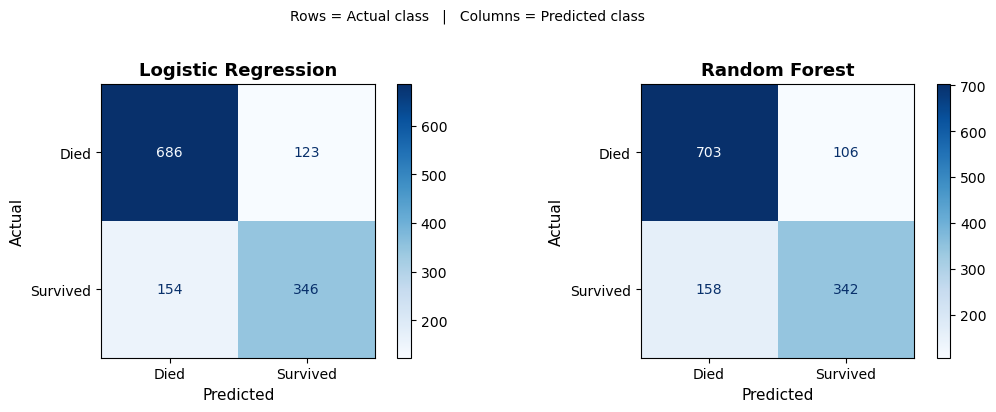

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, pipeline) in zip(axes, [("Logistic Regression", lr_pipeline), ("Random Forest", rf_pipeline)]):
    y_pred = cross_val_predict(pipeline, X, y, cv=cv)
    ConfusionMatrixDisplay.from_predictions(
        y, y_pred,
        display_labels=["Died", "Survived"],
        cmap="Blues",
        ax=ax
    )
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)

plt.suptitle("Rows = Actual class   |   Columns = Predicted class", fontsize=10, y=1.02)
plt.tight_layout()
plt.show()